### This part of the analysis seeks to answer whether the delivery deadlines are being met in relation to what has been established.

In [9]:
import os
from sqlalchemy import create_engine
import psycopg2
from dotenv import load_dotenv
import pandas as pd
import numpy as np

In [4]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

In [30]:

try:
    engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")
    query = """
    select
           (order_approved_at::date - order_purchase_timestamp::date) as purchase_time,
           (order_delivered_carrier::date - order_approved_at::date) as shipping_time,
           delivery_delay_days
    from
        analytics.fact_orders
    WHERE
        order_approved_at is not null
        and order_delivered_carrier is not null
        and delivery_delay_days is not null
    """
    time_dataset_df = pd.read_sql(query, con=engine)
    print("---Data set details---")
    print(time_dataset_df.head(5))

except Exception as e:
    print(f"Detail error: {e}")
finally:
    engine.dispose()

---Data set details---
   purchase_time  shipping_time  delivery_delay_days
0              0              8                 -3.0
1              0              2                -14.0
2              2              0                -15.0
3              1              8                  0.0
4              0              3                -11.0


In [32]:
time_dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110180 entries, 0 to 110179
Data columns (total 3 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   purchase_time        110180 non-null  int64  
 1   shipping_time        110180 non-null  int64  
 2   delivery_delay_days  110180 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.5 MB


In [33]:
time_dataset_df.describe()

,purchase_time,shipping_time,delivery_delay_days
count,110180.000000,110180.000000,110180.000000
mean,0.524170,2.745072,-12.029016
std,0.981086,3.597240,10.159863
min,0.000000,-171.000000,-147.000000
25%,0.000000,1.000000,-17.000000
50%,0.000000,2.000000,-13.000000
75%,1.000000,4.000000,-7.000000
max,31.000000,126.000000,188.000000


<function matplotlib.pyplot.show(close=None, block=None)>

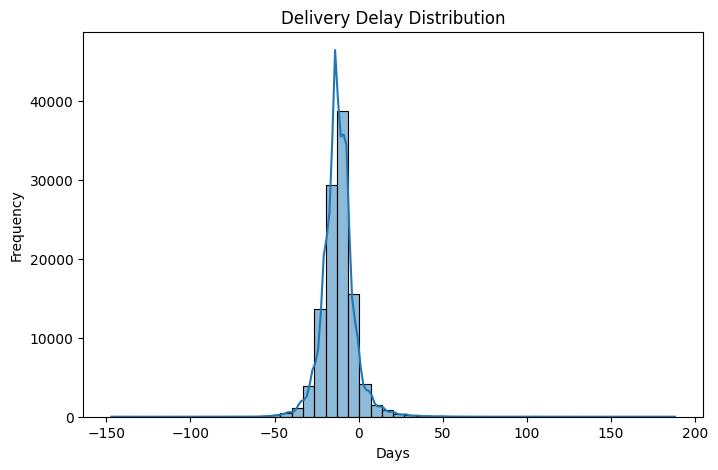

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(time_dataset_df['delivery_delay_days'], bins=50, kde=True)
plt.title("Delivery Delay Distribution")
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show

Text(0.5, 1.0, 'Outlier values')

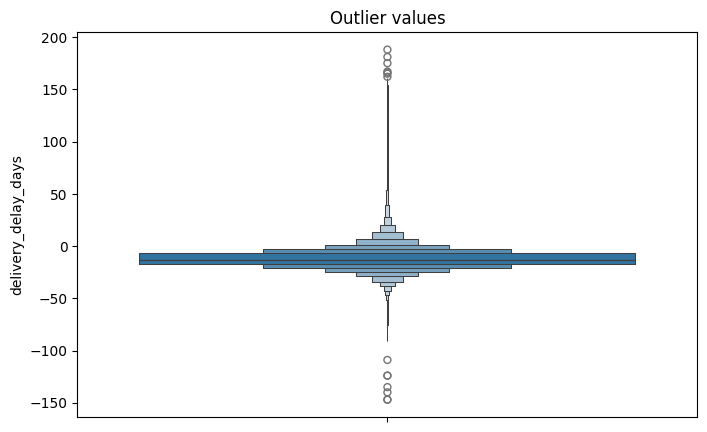

In [41]:
f, ax = plt.subplots(figsize=(8,5))
fig = sns.boxenplot(y="delivery_delay_days", data = time_dataset_df)
plt.title("Outlier values")

<function matplotlib.pyplot.show(close=None, block=None)>

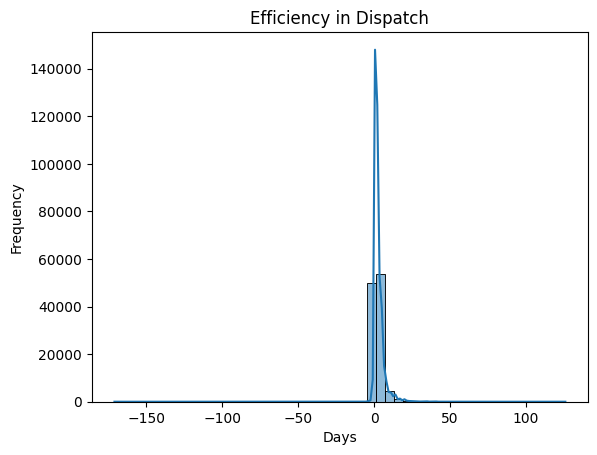

In [39]:
plt.Figure(figsize=(8,5))
sns.histplot(time_dataset_df["shipping_time"], bins=50, kde=True)
plt.title("Efficiency in Dispatch")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show

##### On-Time Delivery Rate (OTD)

In [35]:
(time_dataset_df['delivery_delay_days'] <= 0).mean() * 100

np.float64(93.40715193320021)